# Motivation

The price changes of cryptocurrencies have historically exhibited a strong 'momentum' effect. This effect has been particularly noticeable at regular, 4 year intervals for the past 16 years. Every 4 years, the reward for mining Bitcoin halves creating an undersupply in the market, pushing up prices. Since becoming common knowledge, this effect has been compounded by expectations that prices will rise around the next halving. The last Bitcoin halving event was mid 2024, so a momentum trading bot was set up to capitalise on the associated momentum from December 2024 to Febraury 2025.

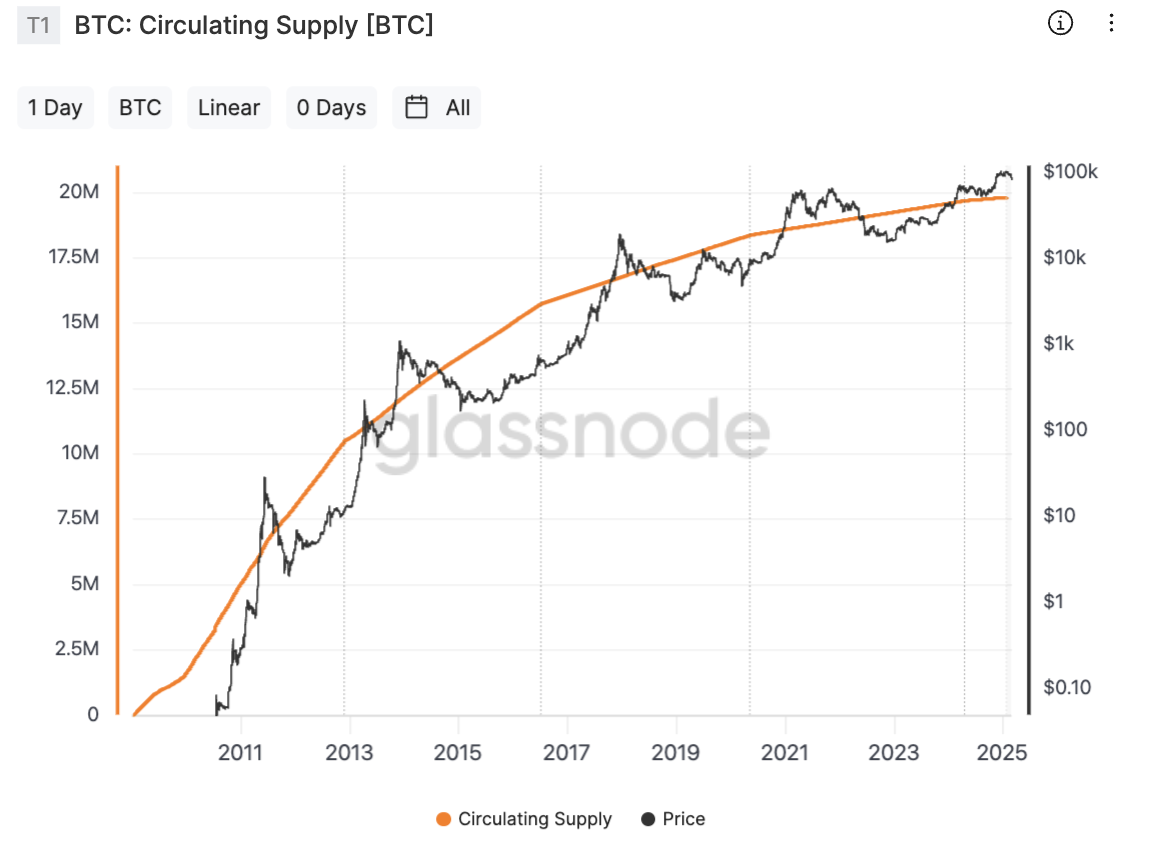

In [ ]:
#4 Yearly Bitcoin supply/price cycle.

from IPython.display import Image, display
display(Image(filename='btc.png'))

In [18]:
import os

# Define folder and file name
folder_name = "Index_Derivatives_Calendar_Spreads"
file_name = "index.html"
file_path = os.path.join(folder_name, file_name)

# Create the folder if it doesn't exist
os.makedirs(folder_name, exist_ok=True)

# HTML content similar to the Trading Models page
html_content = '''<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Index Derivatives Calendar Spreads</title>
  <style>
    body {
      font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
      background-color: #f4f4f9;
      margin: 0;
      padding: 0;
    }
    header {
      background-color: #2c3e50;
      color: white;
      padding: 20px 0;
      text-align: center;
    }
    main {
      max-width: 800px;
      margin: 40px auto;
      padding: 0 20px;
    }
    h1 {
      margin-bottom: 10px;
    }
    ul {
      list-style: none;
      padding: 0;
    }
    li {
      background-color: white;
      margin: 10px 0;
      padding: 15px;
      border-radius: 8px;
      box-shadow: 0 2px 5px rgba(0,0,0,0.1);
    }
    a {
      text-decoration: none;
      color: #3498db;
      font-weight: bold;
    }
    a:hover {
      text-decoration: underline;
    }
    footer {
      text-align: center;
      padding: 20px;
      font-size: 0.9em;
      color: #777;
    }
  </style>
</head>
<body>
  <header>
    <h1>Index Derivatives Calendar Spreads</h1>
    <p>Explore strategies involving calendar spreads in index derivatives</p>
  </header>
  <main>
    <section>
      <ul>
        <li><a href="#">Strategy Overview</a></li>
        <li><a href="#">Backtesting Results</a></li>
        <li><a href="#">Live Deployment</a></li>
      </ul>
      <p><a href="../index.html">← Back to Home</a></p>
    </section>
  </main>
  <footer>
    &copy; 2025 Jackson Watson | Hosted on GitHub Pages
  </footer>
</body>
</html>
'''

# Write the HTML content to the file
with open(file_path, "w") as f:
    f.write(html_content)

print(f"Folder '{folder_name}' and file '{file_name}' created successfully.")


Folder 'Index_Derivatives_Calendar_Spreads' and file 'index.html' created successfully.


#
#
#
#
#
#
#
#
#
#
# Backtest Data

5 years of historical, 4 hourly data was collected from the free Binance API. 100 cryptocurrencies were considered.

In [2]:
#Considered Symbols

symbols = {
    "AAVEUSDT", "ADAUSDT", "AEROUSDT", "AIOZUSDT", "AKTUSDT", "APEUSDT", "ARBUSDT", "ATOMUSDT", "AVAXUSDT", "AXSUSDT",
    "BABYDOGEUSDT", "BEAMUSDT", "BNBUSDT", "BONKUSDT", "BRETTUSDT", "BTCUSDT", "CHILLGUYUSDT", "DOGEUSDT", "DOTUSDT", 
    "EGLDUSDT", "ENJUSDT", "EOSUSDT", "ETHUSDT", "FETUSDT", "FILUSDT", "FLOKIUSDT", "FLOWUSDT", "FLRUSDT", "GALAUSDT", 
    "GMTUSDT", "GOATUSDT", "GRASSUSDT", "GRTUSDT", "HBARUSDT", "HNTUSDT", "ICPUSDT", "IMXUSDT", "INJUSDT", "IOTAUSDT", 
    "JUPUSDT", "LINKUSDT", "MANAUSDT", "MEWUSDT", "MNTUSDT", "MOGUSDT", "NEARUSDT", "NOTUSDT", "OMUSDT", "OPUSDT", 
    "PEPEUSDT", "PNUTUSDT", "POLUSDT", "POPCATUSDT", "PRIMEUSDT", "PYTHUSDT", "QNTUSDT", "RAYUSDT", "RENDERUSDT", "RONUSDT", 
    "ROSEUSDT", "RSRUSDT", "SANDUSDT", "SHIBUSDT", "SOLUSDT", "STRKUSDT", "STXUSDT", "SUIUSDT", "SUPERUSDT", "TAOUSDT", 
    "THETAUSDT", "TIAUSDT", "TONUSDT", "TURBOUSDT", "UNIUSDT", "VIRTUALUSDT", "WIFUSDT", "XLMUSDT", "XRPUSDT"
}

In [12]:
#Collect data

import pandas as pd
import numpy as np
from binance.client import Client
client = Client()
import warnings
warnings.simplefilter(action='ignore')

def get_historical_klines(symbol, interval, start_str, end_str=None):
    import pandas as pd
    import numpy as np
    from binance.client import Client
    client = Client()
    import warnings
    warnings.simplefilter(action='ignore')

    """Get historical klines from Binance"""
    try:
        klines = client.get_historical_klines(
            symbol=symbol,
            interval=interval,
            start_str=start_str,
            end_str=end_str
        )
        
        df = pd.DataFrame(klines, columns=[
            'timestamp', 'open', 'high', 'low', 'close', 'volume',
            'close_time', 'quote_asset_volume', 'number_of_trades',
            'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore'
        ])
        
        # Convert timestamp to datetime
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        
        # Convert price columns to float
        price_cols = ['open', 'high', 'low', 'close']
        df[price_cols] = df[price_cols].astype(float)
        
        df.set_index('timestamp', inplace=True)
        return df
        
    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

cypto_pair_dataframes = [] 

for symbol in symbols:
    try:
        df = get_historical_klines(symbol, Client.KLINE_INTERVAL_4HOUR, "1 Jan, 2020", None)
        df = df.rename(columns={'open': 'Open', 'close': 'Close'})
        df = df.reset_index().rename(columns={'timestamp': 'Open Time'})
        cypto_pair_dataframes.append(df)
        
    except:
        pass

cypto_pair_dataframes[-1]

Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: HTTPSConnectionPool(host='api.binance.com', port=443): Read timed out. (read timeout=10)
Error fetching data: APIError(code=-1121): Invalid symbol.
Error fetching data: APIError(code=-1121): Invalid symbol.


,Open Time,Open,high,low,Close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
0,2025-04-11 12:00:00,0.4199,0.6000,0.4199,0.5245,9481966.70000000,1744387199999,5149153.37936000,22085,4568729.10000000,2487255.38341000,0
1,2025-04-11 16:00:00,0.5243,0.5386,0.5121,0.5297,5672210.30000000,1744401599999,3000145.67185000,18008,2822391.50000000,1493363.82010000,0
2,2025-04-11 20:00:00,0.5304,0.5420,0.5206,0.5280,2445784.70000000,1744415999999,1297345.00816000,5329,1340710.90000000,712102.63213000,0
3,2025-04-12 00:00:00,0.5283,0.5565,0.5195,0.5398,5204172.60000000,1744430399999,2847205.10424000,13322,2608554.30000000,1428661.98395000,0
4,2025-04-12 04:00:00,0.5402,0.5690,0.5325,0.5670,6517854.00000000,1744444799999,3625089.74981000,20051,3516188.80000000,1959829.51329000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
898,2025-09-08 04:00:00,1.1798,1.2100,1.1660,1.1841,6171252.40000000,1757318399999,7363206.38965000,64900,3413924.60000000,4076615.61517000,0
899,2025-09-08 08:00:00,1.1842,1.2053,1.1769,1.1877,1937534.40000000,1757332799999,2312031.78844000,29706,801876.40000000,956844.82115000,0
900,2025-09-08 12:00:00,1.1875,1.2900,1.1827,1.2709,6595501.70000000,1757347199999,8244701.78664000,89240,3509895.70000000,4396142.57956000,0
901,2025-09-08 16:00:00,1.2709,1.2774,1.2457,1.2476,3389759.40000000,1757361599999,4279549.02529000,46187,1598274.60000000,2019928.18457000,0


#
#
#
#
#
#
#
#
#
#
# Strategy

Exponential Moving Averages (EMA) track the recent, dicrete time price history of an asset. For example, EMA10 considers the last 10 time periods of an asset and uses them to create an average price which weights more recent observations (out of the last 10) more highly. When EMAs cross (such as EMA10 and EMA20) this suggests that the recent prices of an asset are either higher or lower than their longer run average. EMA crosses are thus common signals for entering and exiting momentum trades. Buying assets when EMA10 crosses above EMA20 (in 4 hour candles) and selling when it crosses back below was simulated over the past 5 years for all 100 assets that had price data on Binance.

In [15]:
# Simulate trades across cryptos and collect them in a dataframe called bets


def ema_strat(df, strat):
    strat_name = strat[0]+strat[1]
    
    # Calculate EMAs
    df[strat[0]] = df['Close'].ewm(span=strat[2], adjust=False).mean()
    df[strat[1]] = df['Close'].ewm(span=strat[3], adjust=False).mean()

    profits = {}
    #profits1 stores the buy point so that it can combined with the sell point to work out profit per trade
    profits1 = {}
    profits[strat_name] = 0
    profits1[strat_name] = 0
    columns = ['date', 'return']
    df_made = pd.DataFrame(columns=columns)

    #tracker changes value every time there's a buy or a sell
    tracker = 0
    #start helps handle the first couple of trades in the dataset (because they're sort of edge cases for the algorithm)
    start = 0
    for row in df.index:
        #10 has just gone above 20
        if df.loc[row,strat[0]]>df.loc[row,strat[1]] and (tracker == 0 or start == 0):
            tracker = 1
            #below records results of trade from previous period
            if start != 0:
                profits[strat_name] -= (df.loc[row,'Close'] - profits1[strat_name])/profits1[strat_name]
                profits[strat_name] -= 0.0025
                df_made.loc[len(df_made)] = [df.loc[row,'Open Time'],-(df.loc[row,'Close'] - profits1[strat_name])/profits1[strat_name]-0.0025]
            #store buy point of new trade (every time we close a trade we're starting a new one)
            profits1[strat_name] = df.loc[row,'Close']
            start = 1
        #10 has just gone below 20
        elif df.loc[row,strat[0]]<df.loc[row,strat[1]] and (tracker == 1 or start == 0):
            tracker = 0
            #below records results of trade from previous period
            if start != 0:
                profits[strat_name] += (df.loc[row,'Close'] - profits1[strat[0]+strat[1]])/profits1[strat_name]
                profits[strat_name] -= 0.0025
                df_made.loc[len(df_made)] = [df.loc[row,'Open Time'],(df.loc[row,'Close'] - profits1[strat_name])/profits1[strat_name]-0.0025]
            #store buy point of new trade (every time we close a trade we're starting a new one)
            profits1[strat[0]+strat[1]] = df.loc[row,'Close']
            start = 1
    return [profits,df_made]

strats = ['EMA_10','EMA_20',10,20]
bets = 0 

for df in cypto_pair_dataframes:
    try:
        p = ema_strat(df, strats)
        if type(bets)==int:
            bets = p[1]
        else:
            bets = pd.concat([bets, p[1]], ignore_index=True)
        
    except:
        pass

bets['date'] = pd.to_datetime(bets['date'])
bets = bets.sort_values(by='date', ascending=True).reset_index(drop=True)
bets

,date,return
0,2020-01-01 08:00:00,-0.019076
1,2020-01-01 08:00:00,-0.023694
2,2020-01-01 08:00:00,-0.006616
3,2020-01-01 08:00:00,-0.004542
4,2020-01-01 08:00:00,-0.028059
...,...,...
22297,2025-09-08 12:00:00,-0.035878
22298,2025-09-08 16:00:00,0.042306
22299,2025-09-08 16:00:00,-0.032319
22300,2025-09-08 16:00:00,0.042613


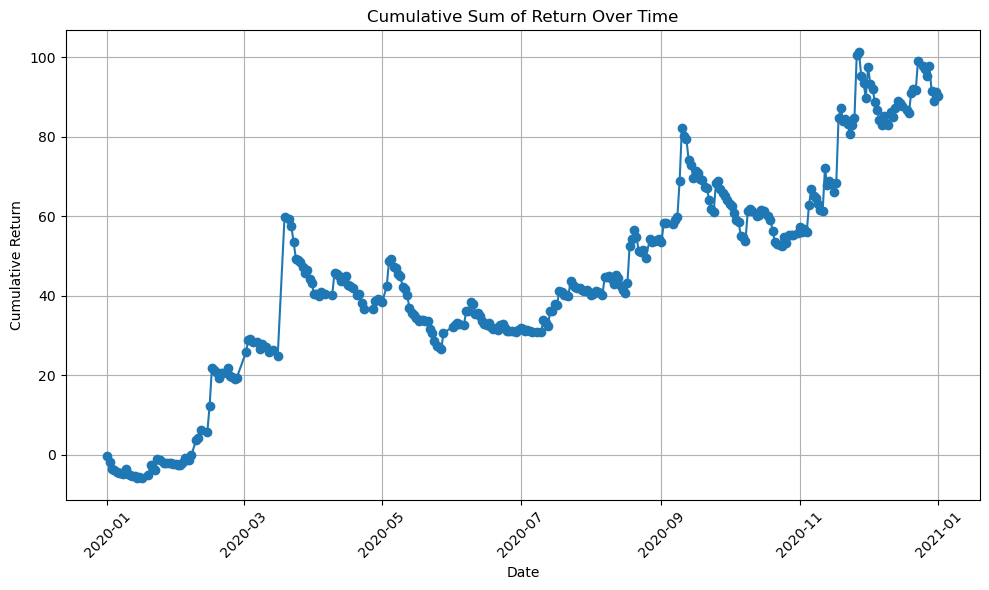

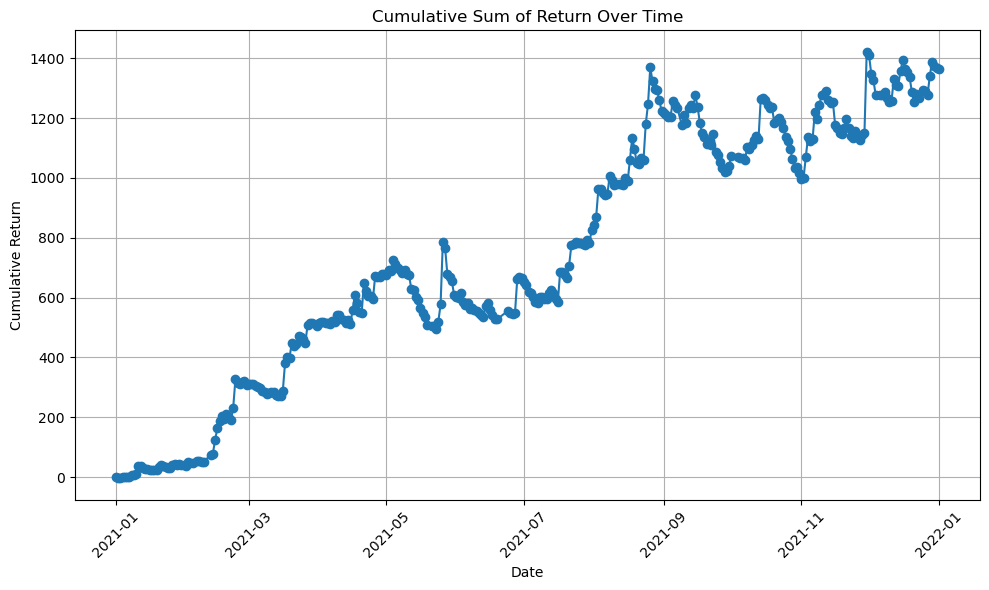

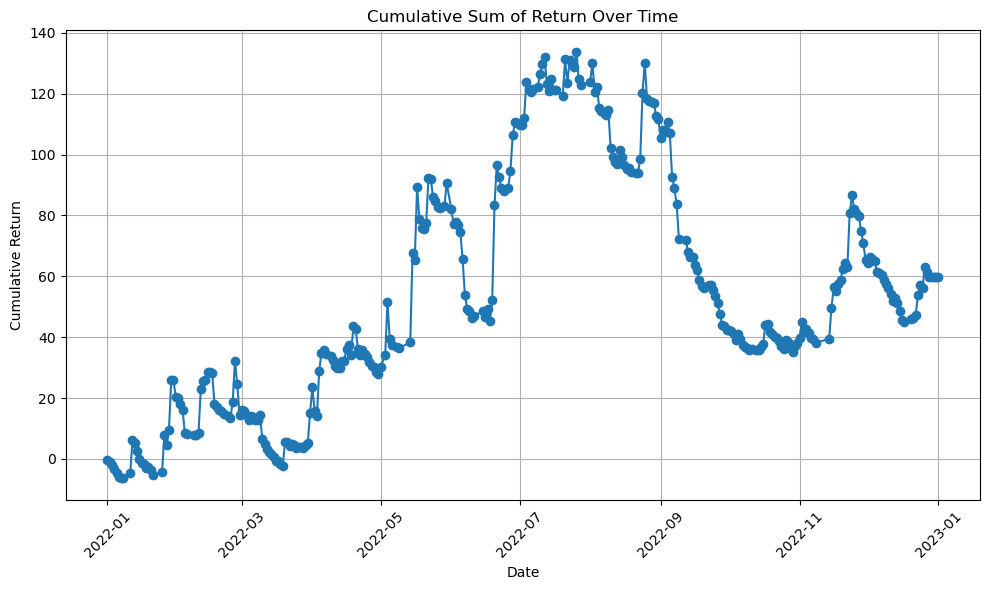

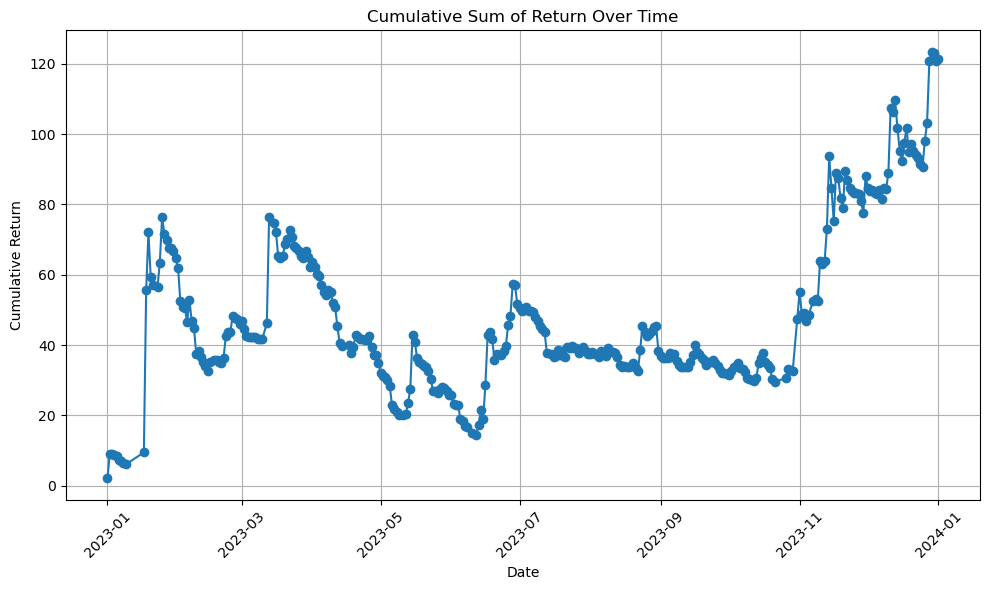

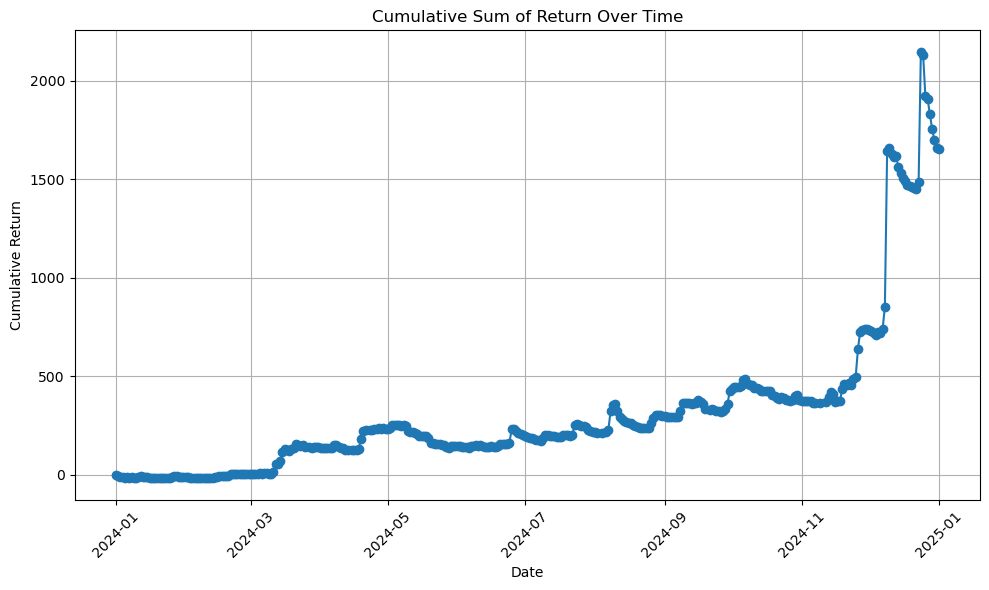

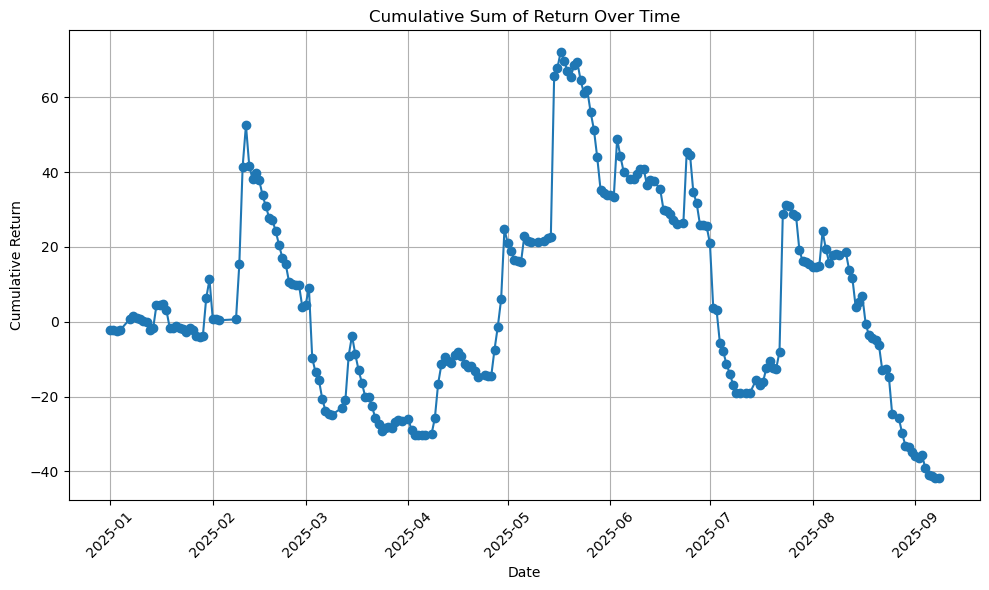

In [17]:
# Graph the cumulative $ return for each year (assuming that each year started with $100 in the account and 1/100 of the running account total was used in each trade with 3x leverage)

leverage = 3


for year in range(2020, 2026):  # Assuming we want to go through each year up to 2025
    start = f'{year}-01-01 08:00:00'
    end = f'{year+1}-01-01 08:00:00'
    # The rest of the code that uses start1 and end1 would be placed here

    bets1 = bets.copy()
    bets1 = bets1[bets1['date'] > start]
    bets1 = bets1[bets1['date'] < end]


    start = 100
    for i in bets1.index:
        bets1.loc[i,'return'] = (start/(len(symbols)))*bets1.loc[i,'return']*leverage
        start += bets1.loc[i,'return']

    daily_returns = bets1.groupby(bets1['date'].dt.date)['return'].sum()
    df = pd.DataFrame(daily_returns)

    # Calculate the cumulative sum of the 'return' column
    df['cumulative_return'] = df['return'].cumsum()

    # Plot the cumulative sum of return against time
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['cumulative_return'], marker='o')
    plt.title('Cumulative Sum of Return Over Time')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#
#
#
#
#
#
#
#
#
#
# Results

As the above plots show, EMA cross strategies are high upside low downside ways of trying to capture large momentum moves when one believes market conditions are favourable. Furthermore, it is shown that the strategy works best around bitcoing halving events (2020 and 2024). AWS was used to set up an autonomous trading bot which applied the above strategy to 80 cryptocurrencies synchronously. It was an EC2 instance scheduled using tmux which gave valuable experience in cloud computing. Unfortunately, the 3 month period (Dec 2024-Feb 2025) when the bot was active didn't see the Bitcoin halving momentum from 2024 continue so it was discontinued.